# Explicabilidad: SHAP para XGBoost + ROS refinado

Este notebook explica el modelo final del proyecto —`xgboost_refinado.joblib`,
con el umbral y las bandas de riesgo definidos en `06_refinamiento_modelo.ipynb`—
mediante SHAP (SHapley Additive exPlanations). Cubre dos niveles:

1. **Importancia global**: qué variables influyen más, en promedio, sobre
   las predicciones del modelo.
2. **Explicación local**: para tres clientes concretos del conjunto de
   prueba, qué variables empujaron su probabilidad de abandono hacia
   arriba o hacia abajo.

**Aclaración importante**: SHAP explica las **asociaciones que el modelo
aprendió**, no relaciones causales. Que una variable tenga un valor SHAP
alto significa que el modelo la usó para esa predicción, no que esa
variable *cause* el abandono.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

import shap

from sklearn.metrics import accuracy_score, precision_score, recall_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Versión de shap:", shap.__version__)

Versión de shap: 0.52.0


## 1. Carga de artefactos

Se carga el modelo refinado (no el baseline), el umbral de decisión, y los
mismos splits preprocesados usados en el resto del proyecto.

In [2]:
ruta_artefactos = Path("../artifacts")
ruta_modelos = Path("../models")
ruta_figuras = Path("../figures")

artefactos = joblib.load(ruta_artefactos / "splits_preprocesados.joblib")
X_train = artefactos["X_train"]
X_val = artefactos["X_val"]
X_test = artefactos["X_test"]
y_train = artefactos["y_train"]
y_val = artefactos["y_val"]
y_test = artefactos["y_test"]
nombres_variables = artefactos["nombres_variables"]

modelo = joblib.load(ruta_modelos / "xgboost_refinado.joblib")

with open(ruta_modelos / "config_umbral.json", encoding="utf-8") as f:
    config_umbral = json.load(f)

umbral_decision = config_umbral["umbral_decision"]

print("Modelo cargado: xgboost_refinado.joblib")
print("Umbral de decisión:", umbral_decision)
print("Variables (58):", len(nombres_variables))

Modelo cargado: xgboost_refinado.joblib
Umbral de decisión: 0.56
Variables (58): 58


## 2. Nombres de variables legibles

`nombres_variables` trae los prefijos técnicos del `ColumnTransformer`
(`numericas__` / `categoricas__`). Se construye un mapeo a nombres
legibles para que los gráficos de SHAP se entiendan sin conocer el
pipeline de preprocesamiento.

In [3]:
with open(ruta_artefactos / "esquema_entrada.json", encoding="utf-8") as f:
    esquema_entrada = json.load(f)

variables_categoricas_originales = sorted(
    esquema_entrada["categoricas"].keys(), key=len, reverse=True
)


def nombre_legible(nombre_tecnico):
    if nombre_tecnico.startswith("numericas__"):
        return nombre_tecnico.replace("numericas__", "")
    if nombre_tecnico.startswith("categoricas__"):
        resto = nombre_tecnico.replace("categoricas__", "")
        for variable in variables_categoricas_originales:
            prefijo = variable + "_"
            if resto.startswith(prefijo):
                valor = resto[len(prefijo):]
                return f"{variable} = {valor}"
        return resto
    return nombre_tecnico


nombres_legibles = [nombre_legible(n) for n in nombres_variables]

X_train_df = pd.DataFrame(X_train, columns=nombres_legibles)
X_val_df = pd.DataFrame(X_val, columns=nombres_legibles)
X_test_df = pd.DataFrame(X_test, columns=nombres_legibles)

print("Ejemplos de nombres legibles:")
for original, legible in list(zip(nombres_variables, nombres_legibles))[:5]:
    print(f"  {original}  ->  {legible}")

Ejemplos de nombres legibles:
  numericas__age  ->  age
  numericas__tenure_months  ->  tenure_months
  numericas__monthly_logins  ->  monthly_logins
  numericas__weekly_active_days  ->  weekly_active_days
  numericas__avg_session_time  ->  avg_session_time


## 3. Explainer de SHAP

Se intentó `TreeExplainer` en espacio de probabilidad (con un fondo de 100 filas de entrenamiento), para que los valores se leyeran directamente como cambios de probabilidad. Ese modo **falló** con `NotImplementedError: Categorical split is not yet supported`: XGBoost 3.x puede construir árboles con splits categóricos nativos, y el modo `interventional` de shap 0.52 todavía no los soporta. El notebook detecta esto automáticamente y usa como respaldo el **espacio de margen (log-odds)**, que sí es compatible.

Esto cambia cómo se leen los números: un valor SHAP de +1,0 no significa "+1,0 puntos de probabilidad", sino que aumenta el log-odds del modelo en 1,0 — empuja la predicción hacia churn, y cuanto mayor el valor absoluto, más fuerte el empuje. Para interpretar cada caso local alcanza con comparar las magnitudes entre variables (cuál pesó más) y el signo (empuja hacia churn o hacia permanencia); no se necesita convertir a puntos de probabilidad para que la explicación sea útil.

In [4]:
fondo = shap.sample(X_train_df, 100, random_state=RANDOM_STATE)

espacio_probabilidad = True
try:
    explainer = shap.TreeExplainer(
        modelo,
        data=fondo,
        model_output="probability",
        feature_perturbation="interventional",
    )
    # Prueba rápida para confirmar que el modo probabilidad funciona
    _ = explainer(X_val_df.iloc[:5])
    print("Explainer creado en espacio de PROBABILIDAD.")
except Exception as error:
    print(f"Modo probabilidad falló ({error!r}); usando espacio de margen (log-odds) como respaldo.")
    espacio_probabilidad = False
    explainer = shap.TreeExplainer(modelo)

Modo probabilidad falló (NotImplementedError('Categorical split is not yet supported. You can still use TreeExplainer with `feature_perturbation=tree_path_dependent`.')); usando espacio de margen (log-odds) como respaldo.


## 4. Importancia global

Se calculan los valores SHAP sobre el conjunto de validación completo
(1.500 casos) y se grafican la importancia global (barras, promedio del
valor absoluto) y el resumen tipo *beeswarm* (dirección y magnitud del
efecto de cada variable).

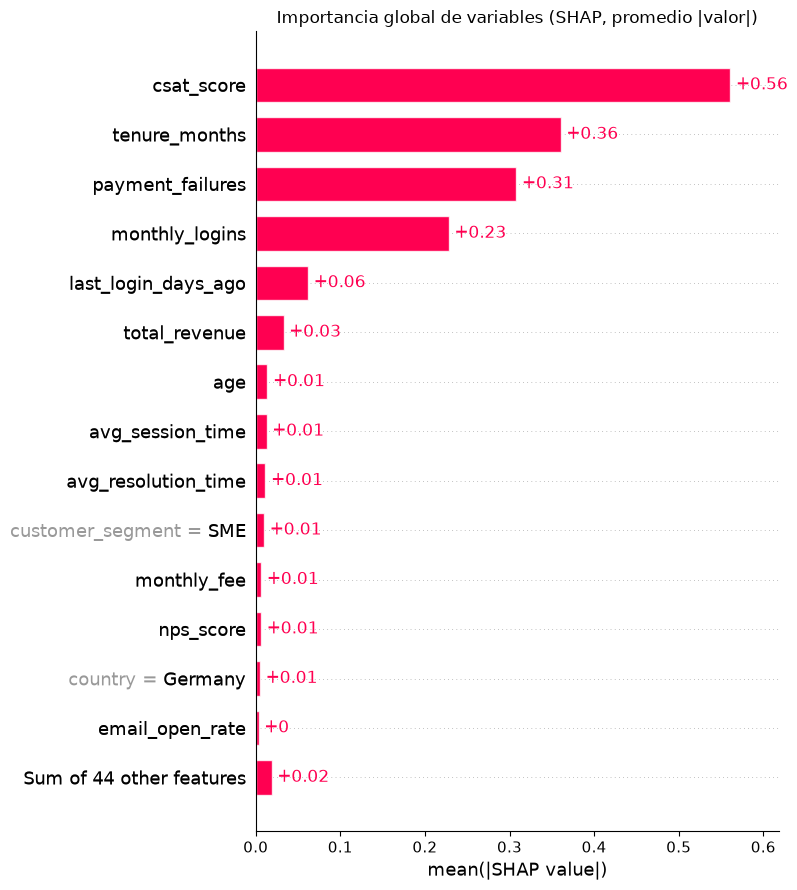

In [5]:
explicacion_val = explainer(X_val_df)

fig = plt.figure(figsize=(9, 7))
shap.plots.bar(explicacion_val, max_display=15, show=False)
plt.title("Importancia global de variables (SHAP, promedio |valor|)")
plt.tight_layout()
plt.savefig(ruta_figuras / "12_01_shap_importancia_global_bar.png", dpi=150, bbox_inches="tight")
plt.show()

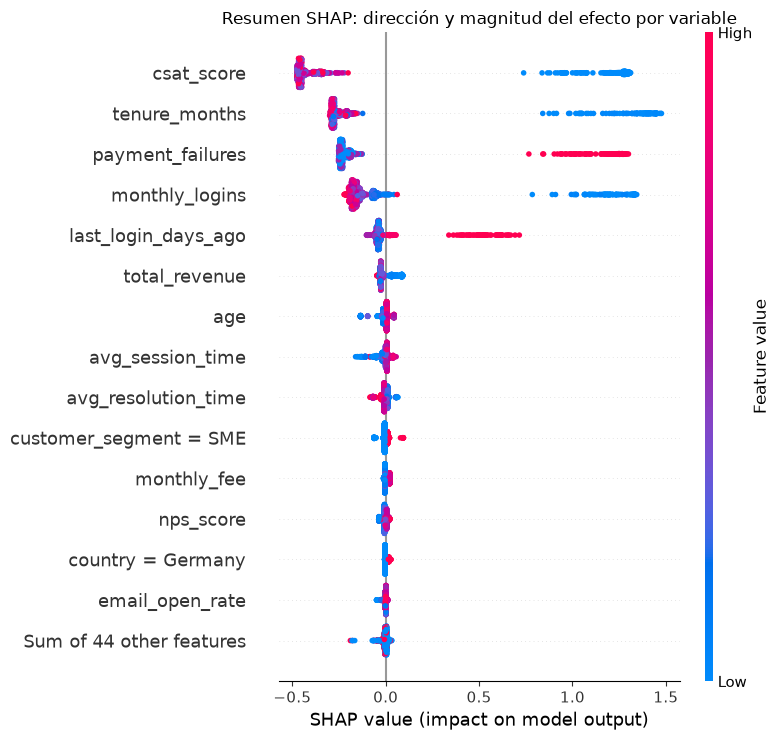

In [6]:
fig = plt.figure(figsize=(9, 8))
shap.plots.beeswarm(explicacion_val, max_display=15, show=False)
plt.title("Resumen SHAP: dirección y magnitud del efecto por variable")
plt.tight_layout()
plt.savefig(ruta_figuras / "12_02_shap_resumen_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
importancia_global = pd.DataFrame({
    "variable": nombres_legibles,
    "importancia_media_abs": np.abs(explicacion_val.values).mean(axis=0),
}).sort_values("importancia_media_abs", ascending=False).reset_index(drop=True)

importancia_global.to_csv(ruta_modelos / "shap_importancia_global.csv", index=False)
importancia_global.head(15)

,variable,importancia_media_abs
0,csat_score,0.561049
1,tenure_months,0.360554
2,payment_failures,0.308113
3,monthly_logins,0.228238
4,last_login_days_ago,0.061951
5,total_revenue,0.032903
6,age,0.013872
7,avg_session_time,0.012855
8,avg_resolution_time,0.011542
9,customer_segment = SME,0.009965


## 5. Explicaciones locales (conjunto de prueba)

Se seleccionan tres casos del conjunto de prueba para ilustrar cómo se ve
una explicación individual:

1. Un **verdadero positivo**: el modelo lo marcó correctamente como alto
   riesgo y el cliente efectivamente abandonó.
2. Un **falso positivo**: el modelo lo marcó como alto riesgo, pero el
   cliente permaneció (sustenta la discusión honesta sobre la precision
   del modelo).
3. Un **verdadero negativo confiado**: probabilidad baja y el cliente
   efectivamente permaneció.

Usar casos de prueba (y no de validación) es válido aquí porque SHAP es
explicativo, no una decisión de modelamiento: no se está seleccionando
ni ajustando nada con esta elección, solo ilustrando el comportamiento
del modelo ya fijado sobre los mismos casos que arrojaron las métricas
finales reportadas.

In [8]:
proba_test = modelo.predict_proba(X_test)[:, 1]
prediccion_test = (proba_test >= umbral_decision).astype(int)
y_test_np = y_test.to_numpy()

idx_verdadero_positivo = np.where((y_test_np == 1) & (prediccion_test == 1))[0]
idx_falso_positivo = np.where((y_test_np == 0) & (prediccion_test == 1))[0]
idx_verdadero_negativo = np.where((y_test_np == 0) & (prediccion_test == 0))[0]

# Verdadero positivo con mayor probabilidad (caso más claro)
caso_vp = idx_verdadero_positivo[np.argmax(proba_test[idx_verdadero_positivo])]
# Falso positivo con mayor probabilidad (el más "cercano a parecer" un abandono real)
caso_fp = idx_falso_positivo[np.argmax(proba_test[idx_falso_positivo])]
# Verdadero negativo con menor probabilidad (caso más confiado)
caso_vn = idx_verdadero_negativo[np.argmin(proba_test[idx_verdadero_negativo])]

print(f"Verdadero positivo: fila {caso_vp}, probabilidad {proba_test[caso_vp]:.3f}")
print(f"Falso positivo:     fila {caso_fp}, probabilidad {proba_test[caso_fp]:.3f}")
print(f"Verdadero negativo: fila {caso_vn}, probabilidad {proba_test[caso_vn]:.3f}")

Verdadero positivo: fila 1385, probabilidad 0.941
Falso positivo:     fila 1401, probabilidad 0.938
Verdadero negativo: fila 316, probabilidad 0.218


In [9]:
explicacion_test = explainer(X_test_df)

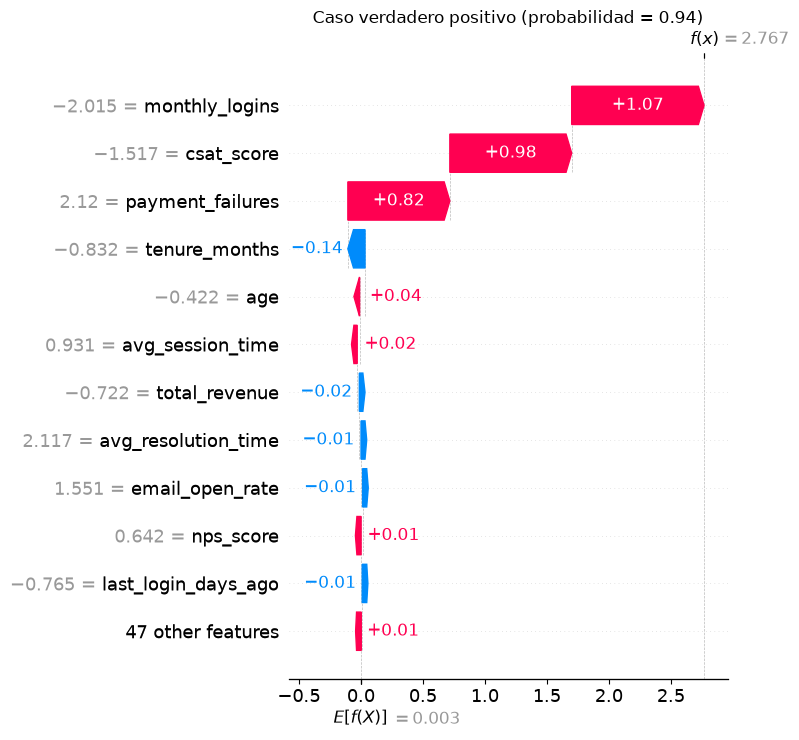

In [10]:
fig = plt.figure(figsize=(9, 6))
shap.plots.waterfall(explicacion_test[caso_vp], max_display=12, show=False)
plt.title(f"Caso verdadero positivo (probabilidad = {proba_test[caso_vp]:.2f})")
plt.tight_layout()
plt.savefig(ruta_figuras / "12_03_shap_local_verdadero_positivo.png", dpi=150, bbox_inches="tight")
plt.show()

Este cliente fue detectado correctamente como alto riesgo (probabilidad 0,941). Las tres variables que más empujaron la predicción hacia churn fueron `monthly_logins` (muy por debajo del promedio), `csat_score` (satisfacción muy por debajo del promedio) y `payment_failures` (bastantes más fallos de pago que el promedio). Es el perfil de manual: cliente poco activo, insatisfecho y con problemas de pago — exactamente las variables que ya habían aparecido como las más relevantes en el análisis exploratorio (sección 4.1.6) y en la importancia global de esta sección.

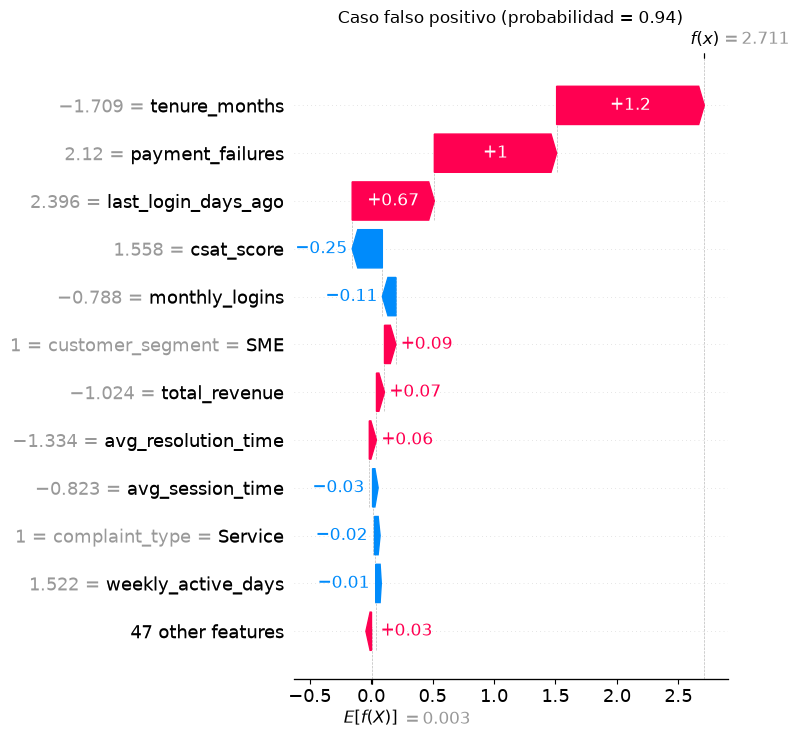

In [11]:
fig = plt.figure(figsize=(9, 6))
shap.plots.waterfall(explicacion_test[caso_fp], max_display=12, show=False)
plt.title(f"Caso falso positivo (probabilidad = {proba_test[caso_fp]:.2f})")
plt.tight_layout()
plt.savefig(ruta_figuras / "12_04_shap_local_falso_positivo.png", dpi=150, bbox_inches="tight")
plt.show()

El modelo asignó a este cliente una probabilidad casi idéntica a la del caso anterior (0,938), pero este sí permaneció: es exactamente el tipo de alerta falsa que explica la precision baja del modelo (0,234 en prueba). Las variables que más empujaron hacia churn fueron una antigüedad muy por debajo del promedio (`tenure_months`), más fallos de pago que el promedio (`payment_failures`) y muchos días desde el último acceso (`last_login_days_ago`) — un perfil que en la mayoría de los casos sí anticipa abandono. Sin embargo, este cliente tenía una satisfacción (`csat_score`) por encima del promedio, lo que empujó en sentido contrario, pero con menos fuerza que las señales de riesgo. En otras palabras: el modelo ponderó más la inactividad y los problemas de pago que la buena satisfacción declarada, y en este caso se equivocó.

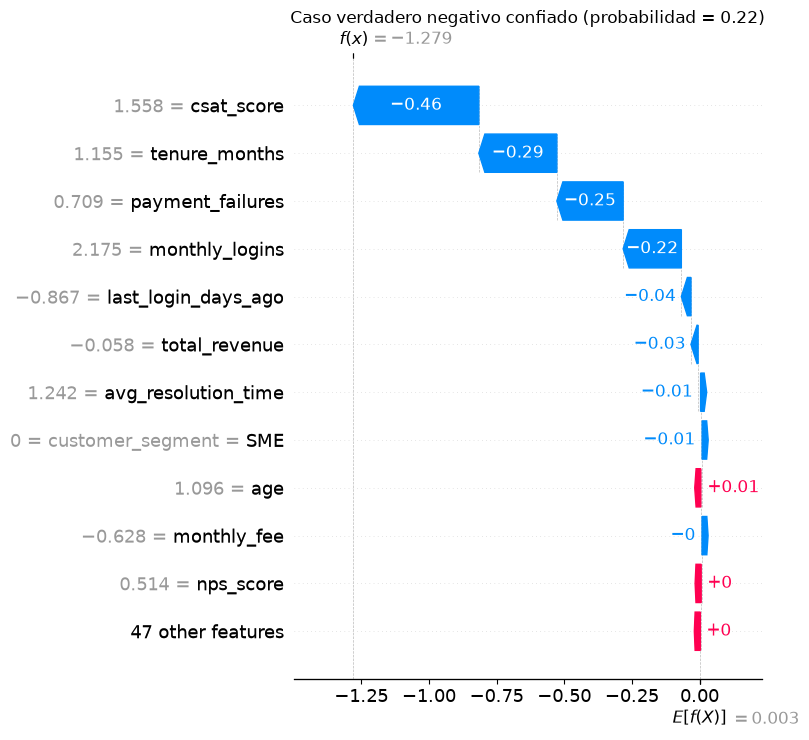

In [12]:
fig = plt.figure(figsize=(9, 6))
shap.plots.waterfall(explicacion_test[caso_vn], max_display=12, show=False)
plt.title(f"Caso verdadero negativo confiado (probabilidad = {proba_test[caso_vn]:.2f})")
plt.tight_layout()
plt.savefig(ruta_figuras / "12_05_shap_local_verdadero_negativo.png", dpi=150, bbox_inches="tight")
plt.show()

Este cliente fue clasificado con probabilidad baja (0,218) y efectivamente permaneció. La satisfacción (`csat_score`) muy por encima del promedio fue, de lejos, la variable que más empujó la predicción hacia "permanece", seguida de una antigüedad (`tenure_months`) y una cantidad de accesos mensuales (`monthly_logins`) también por encima del promedio. Es el perfil inverso al del primer caso: cliente activo, antiguo y satisfecho, y el modelo lo reconoce con confianza razonable.

## 6. Qué se guarda para el prototipo

No se guarda (ni se serializa) el objeto `explainer`: construir un
`TreeExplainer` desde un modelo de árboles ya entrenado es una operación
barata (lee la estructura de árboles), y calcular SHAP para una sola fila
en el momento de la predicción toma milisegundos. El backend de la
aplicación construye el explainer una sola vez al iniciar (cacheado) y
calcula la explicación local en cada solicitud. Lo único que se persiste
aquí es `models/shap_importancia_global.csv`, para que la vista global de
la aplicación no tenga que recalcular SHAP sobre un conjunto de fondo cada
vez que se abre.

## 7. Conclusiones

La importancia global coincide, en gran medida, con lo que ya había aparecido en el análisis exploratorio (sección 4.1.6): `csat_score`, `tenure_months`, `payment_failures` y `monthly_logins` son, en ese orden, las cuatro variables con mayor peso en las predicciones del modelo — las mismas cuatro que mostraron las diferencias de medias (Cohen's d) más grandes entre clientes que permanecen y abandonan. Esto es una señal de consistencia entre el análisis descriptivo inicial y lo que el modelo terminó aprendiendo: no está reaccionando a ruido ni a variables sin sentido de negocio.

Los tres casos locales muestran cómo se combinan esas señales en la práctica. El verdadero positivo y el verdadero negativo son perfiles consistentes (todas las señales apuntan en la misma dirección). El falso positivo es más interesante: muestra un cliente con señales de riesgo fuertes (poca antigüedad, fallos de pago, inactividad reciente) pero con una satisfacción declarada alta que no bastó para cambiar la predicción. Esto sugiere una posible mejora futura: dar más peso relativo a `csat_score` cuando contradice a las demás señales, en vez de tratarlo como una variable más entre varias.

**Aclaración final**: estas explicaciones muestran qué variables *usó el modelo* para cada predicción — es decir, asociaciones que aprendió de los datos de entrenamiento. No son evidencia de que, por ejemplo, mejorar artificialmente el `csat_score` de un cliente vaya a *causar* que deje de abandonar; podría ser que ambas cosas respondan a una causa común (por ejemplo, un mal soporte técnico que afecta la satisfacción y el uso al mismo tiempo). Para decisiones de retención, estas explicaciones sirven para priorizar y entender el riesgo detectado por el modelo, no como receta causal.